#Traffic Monitoring

#Objective: Traffic Monitoring

- Red Light cameras --> Track vehicle trajectory after detection --. Determine it crossed line during red.
- Highway congestion analysis --> Follow groups of cars --> estimate avergae speed, detect stopped vehicles.
- Wrong way driving alert --. track detection --> if car goes opposie to flow --> alarm
- Toll booth/APNR --> Track vehicle from far --> zoom inw hen close for plate reading.

#Steps:

1. Import Video File
2. Video Selection
3. Create Frame
4. Object tracking
5. Drawing Box
6. Testing



In [ ]:
pip install ultralytics opencv-python numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.6 MB/s eta 0:00:00


In [ ]:
from google.colab.patches import cv2_imshow

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files
import time

VIDEO_PATH = "test_video.mp4"
MODEL_PATH = "yolov8n.pt"

# Vehicle classes (COCO dataset)
VEHICLE_CLASSES = [2,3,5,7]

LOW_SPEED_THRESHOLD = 25
MIN_VEHICLES = 8
MIN_LOW_SPEED = 5
CONGESTION_FRAMES = 40

prev_positions = {}
speed_memory = {}
speed_history = {}
last_seen = {}

MAX_MISSING = 30
congestion_counter = 0

model = YOLO(MODEL_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0:
    fps = 30

width = 960
height = 540

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

print("Processing Video...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (width, height))

    results = model.track(frame, persist=True, conf=0.3, iou=0.5, verbose=False)

    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy()
        clss = results[0].boxes.cls.cpu().numpy()

        current_ids = set()

        for box, track_id, cls in zip(boxes, ids, clss):
            if int(cls) not in VEHICLE_CLASSES:
                continue

            x1,y1,x2,y2 = map(int,box)
            cx,cy = int((x1+x2)/2), int((y1+y2)/2)

            current_ids.add(track_id)
            last_seen[track_id] = 0

            if track_id in prev_positions:
                px,py = prev_positions[track_id]
                distance = np.sqrt((cx-px)**2 + (cy-py)**2)
                instant_speed = distance * fps

                if track_id not in speed_history:
                    speed_history[track_id] = []

                speed_history[track_id].append(instant_speed)
                if len(speed_history[track_id]) > 5:
                    speed_history[track_id].pop(0)

                speed = sum(speed_history[track_id]) / len(speed_history[track_id])
                speed_memory[track_id] = speed
            else:
                speed_memory[track_id] = 0

            prev_positions[track_id] = (cx,cy)

            # Draw box
            cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(frame,f"ID:{int(track_id)}",(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)
            cv2.putText(frame,f"Spd:{int(speed_memory[track_id])}",(x1,y2+15),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),2)

        # Remove disappeared vehicles
        for tid in list(last_seen.keys()):
            if tid not in current_ids:
                last_seen[tid]+=1
                if last_seen[tid] > MAX_MISSING*2:
                    last_seen.pop(tid,None)
                    prev_positions.pop(tid,None)
                    speed_memory.pop(tid,None)
                    speed_history.pop(tid,None)

        vehicle_count=len(speed_memory)
        low_speed_count=sum(1 for s in speed_memory.values() if s<LOW_SPEED_THRESHOLD)

        if vehicle_count>MIN_VEHICLES and low_speed_count>MIN_LOW_SPEED:
            congestion_counter+=1
        else:
            congestion_counter=0

        if congestion_counter>CONGESTION_FRAMES:
            cv2.putText(frame,"CONGESTION DETECTED",(50,50),
                        cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,0,255),3)

        # Traffic Level
        if vehicle_count<5:
            level="FREE FLOW"
        elif vehicle_count<12:
            level="MODERATE"
        else:
            level="HEAVY"

        cv2.putText(frame,f"Vehicles:{vehicle_count}",(50,90),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,255),2)
        cv2.putText(frame,f"Slow:{low_speed_count}",(50,120),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,255),2)
        cv2.putText(frame,level,(50,150),
                    cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,0),2)

    out.write(frame)

cap.release()
out.release()

print("Processing Finished!")

Processing Video...
Processing Finished!


#Video Analytics

**🏀 Basketball Match Video Analytics System**
Real-time Player Tracking & Game Event Detection

**Project Overview:**

-Automatically detect players and the basketball in match footage

-Track player movement and ball possession in real time

-Identify shot attempts near the basket area

-Generate live game statistics for performance analysis

-Analyze player activity and match dynamics using computer vision

**Technologies Used:**
- YOLOv8 for object detection
- OpenCV for video processing
- Background subtraction for abandoned object detection
- Real-time alert system

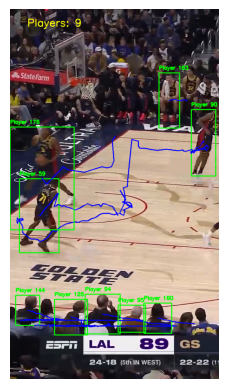

Sports analytics finished!


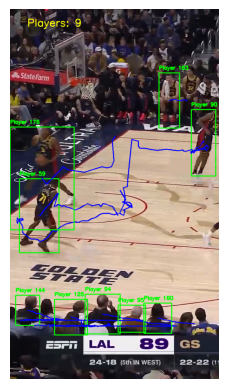

In [ ]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# ===============================
# LOAD MODEL
# ===============================
model = YOLO("yolov8n.pt")

# ===============================
# LOAD VIDEO
# ===============================
video_path = "test.mp4"   # <-- CHANGE to your sports video
cap = cv2.VideoCapture(video_path)

# PERSON CLASS (players)
PERSON_CLASS = 0

# Store player paths
paths = {}

print("Sports analytics running...")

# ===============================
# MAIN LOOP
# ===============================
while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # Track players
    results = model.track(frame, persist=True, conf=0.3)

    player_count = 0

    if results[0].boxes is not None and results[0].boxes.id is not None:

        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy()
        classes = results[0].boxes.cls.cpu().numpy()

        for box, track_id, cls in zip(boxes, ids, classes):

            # Only detect players (person class)
            if int(cls) != PERSON_CLASS:
                continue

            player_count += 1

            x1,y1,x2,y2 = map(int,box)

            cx = int((x1+x2)/2)
            cy = int((y1+y2)/2)

            # Save movement path
            if track_id not in paths:
                paths[track_id] = []

            paths[track_id].append((cx,cy))

            # Draw player box
            cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

            cv2.putText(frame,
                        f"Player {int(track_id)}",
                        (x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,(0,255,0),2)

            # Draw movement trail
            for i in range(1,len(paths[track_id])):
                cv2.line(frame,
                         paths[track_id][i-1],
                         paths[track_id][i],
                         (255,0,0),2)

    # Display player count
    cv2.putText(frame,
                f"Players: {player_count}",
                (50,50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,(0,255,255),2)

    # ===============================
    # SHOW VIDEO IN JUPYTER
    # ===============================
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)
    plt.imshow(frame_rgb)
    plt.axis("off")
    display(plt.gcf())

cap.release()

print("Sports analytics finished!")

#save to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
